# Phase B2 — Statistical evaluation of label sensitivity

Analyze saved 60-s NTSA results for **T30/T60/S3/S5** only. All results remain inline, including `label_sensitivity_statistics`; no CSV, figure or report is exported. No NTSA algorithm or P0 statistical test is rerun.

**Unit:** median of valid windows per rule × session × state × metric, then paired Δ = Drowsy − Awake. Metric-specific validity requires successful computation and finite values; LLE additionally requires primary R² ≥0.90. A missing state is reported and the session is unpaired for that metric. No manual session exclusion is made.

**Framework alignment:** prediction uses the primary exact two-sided signed-rank implementation (average ranks and exact sign enumeration); DET/LLE use primary SciPy Wilcoxon settings (`wilcox`, no correction, two-sided, `auto`). Bootstrap is percentile median CI, 20,000 resamples of paired-session Δ. Primary metric-specific seed conventions are retained independently for every rule. Near-zero tolerance is 10⁻¹².

**Confirmed Simplex aggregation (P0 and B2):** each 60-s window yields CC/NRMSE at 18 prediction horizons, which are averaged into window-level Mean_CC/Mean_NRMSE. Within each session × state, take the median across valid windows, then compute paired Δ = Drowsy − Awake. P0 and T30/T60/S3/S5 therefore use the same session × state estimator for comparing direction, effect magnitude and session consistency. This pipeline description follows the user's confirmation at finalization; no computation is repeated in this documentation update.

**FDR scope:** BH-FDR uses **four headline metrics per label rule**. Saved P0 BH results used seven metrics and remain unchanged; no new P0 aggregation, statistical test or FDR is calculated.

In [1]:
from pathlib import Path
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/label-sensitive-matplotlib")
import hashlib
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib as mpl
from matplotlib import pyplot as plt, font_manager
from matplotlib.lines import Line2D
from IPython.display import display, Markdown

PHASE1_DIR = next(p / "phase1" for p in [Path.cwd(), *Path.cwd().parents] if (p / "phase1/src").is_dir())
INPUT_DIR = PHASE1_DIR / "results/ntsa_label_sensitive"
RULES = ("T30", "T60", "S3", "S5")
METRICS = ("Mean_CC", "Mean_NRMSE", "DET", "LLE")
EXPECTED_SIGN = {"Mean_CC":-1, "Mean_NRMSE":1, "DET":-1, "LLE":-1}
EXPECTED_PAIRS = {"T30":20, "T60":20, "S3":20, "S5":19}
N_BOOTSTRAP = 20_000
BOOTSTRAP_SEED = 20260829
ZERO_TOLERANCE = 1e-12
ALPHA = .05
get_ipython().run_line_magic("config", "InlineBackend.figure_formats = {'svg', 'png'}")

def require(condition, message):
    if not condition:
        raise ValueError(message)

def boolean(series):
    values = series.astype(str).str.lower()
    require(values.isin(["true", "false"]).all(), f"Invalid boolean column {series.name}")
    return values.eq("true")

def digest(path):
    with path.open("rb") as stream:
        return hashlib.file_digest(stream,"sha256").hexdigest()

## Input validation and saved P0 references

Require all 20 result files per rule, complete execution counts and unique window IDs. Check saved inclusion, embedding, fit settings and R² flags. Source fingerprints remain in memory for a final read-only verification.

In [2]:
execution = pd.read_csv(INPUT_DIR / "master_execution_summary.csv").set_index("rule")
frames, manifest = [], []
for rule in RULES:
    paths = sorted((INPUT_DIR / rule).glob("session_*_ntsa.csv"))
    require(len(paths)==20, f"{rule}: expected 20 session output files")
    for path in paths:
        frame = pd.read_csv(path, dtype={"session":str}, float_precision="round_trip")
        require(frame.rule.eq(rule).all(), f"Rule mismatch: {path.name}")
        frames.append(frame)
        manifest.append(dict(file=str(path.relative_to(PHASE1_DIR)),sha256=digest(path),rows=len(frame)))
windows = pd.concat(frames,ignore_index=True)
require(not windows.duplicated(["rule","window_id"]).any(), "Duplicate window IDs")
require(windows.state.isin(["Awake","Drowsy"]).all(), "Unexpected state")
require(windows.state.eq(windows.label.map({0:"Awake",1:"Drowsy"})).all(), "State/label mismatch")
require(boolean(windows.analysis_included).all() and windows.duration_s.eq(60).all(), "Nonincluded/non-60-s window")
require(windows.m.eq(8).all() and windows.tau_s.eq(.16).all(), "Embedding parameters differ")
require(np.array_equal(windows.tau_samples,np.rint(.16*windows.fs).astype(int)), "Delay conversion mismatch")
require(windows.target_rr.eq(.02).all(), "RQA target RR differs")
require(windows.requested_fit_start_s.eq(.8).all() and windows.requested_fit_end_s.eq(1.3).all(), "LLE fit differs")
require(np.array_equal(boolean(windows.LLE_pass_R2_090),boolean(windows.lle_success)&windows.LLE_fit_R2.ge(.90)), "LLE QC flag mismatch")
for rule in RULES:
    require(windows.rule.eq(rule).sum()==execution.loc[rule,"input_windows"], f"Incomplete {rule} outputs")

p0_paths = [PHASE1_DIR / "outputs/prediction/prediction_state_comparison_60s_processed.csv",
            PHASE1_DIR / "outputs/rqa/rqa_state_comparison_60s_processed.csv",
            PHASE1_DIR / "outputs/lle/lle_state_comparison_60s_processed.csv"]
p0 = pd.concat([pd.read_csv(path) for path in p0_paths],ignore_index=True)
p0 = p0[p0.metric.isin(METRICS)][["metric","median_delta"]].set_index("metric").reindex(METRICS)
require(len(p0)==4 and p0.median_delta.notna().all() and p0.index.is_unique, "P0 references incomplete")
expected_p0 = np.array([-.0339,.0294,-.0186,-.0376])
require(np.allclose(p0.median_delta, expected_p0, atol=.00005, rtol=0), "P0 differs from supplied rounded reference")
for path in p0_paths:
    manifest.append(dict(file=str(path.relative_to(PHASE1_DIR)),sha256=digest(path),rows=len(pd.read_csv(path))))
display(p0.rename(columns={"median_delta":"saved_P0_delta"}))
print(f"Loaded {len(windows):,} sensitivity windows; P0 references read without recomputation.")

,saved_P0_delta
metric,
Mean_CC,-0.033871
Mean_NRMSE,0.029424
DET,-0.018645
LLE,-0.037570


Loaded 3,393 sensitivity windows; P0 references read without recomputation.


## Metric validity, session medians and paired-session audit

The following coverage table records all 20 sessions for each rule and metric, including those missing a valid state. Expected paired counts are checked **after metric-specific QC**, rather than imposed by selecting sessions. Sessions 09/13 remain eligible under the same rules as every other session.

In [3]:
state_rows, coverage_rows = [], []
for rule in RULES:
    subset = windows[windows.rule==rule]
    for metric in METRICS:
        success_column = "simplex_success" if metric.startswith("Mean_") else "rqa_success" if metric=="DET" else "lle_success"
        valid = boolean(subset[success_column]) & np.isfinite(subset[metric])
        if metric=="LLE":
            valid &= np.isfinite(subset.LLE_fit_R2) & subset.LLE_fit_R2.ge(.90)
        selected = subset.loc[valid]
        summary = selected.groupby(["session","state"])[metric].agg(value="median",n_windows="size").reset_index()
        summary["rule"], summary["metric"] = rule, metric
        state_rows.append(summary)
        for session in sorted(subset.session.unique()):
            counts = summary[summary.session==session].set_index("state").n_windows
            na,nd=int(counts.get("Awake",0)),int(counts.get("Drowsy",0))
            coverage_rows.append(dict(rule=rule,metric=metric,session=session,awake_valid_windows=na,drowsy_valid_windows=nd,
                                     paired=bool(na and nd),reason="" if na and nd else "Missing valid "+("Awake" if not na else "Drowsy")))
session_state_values = pd.concat(state_rows,ignore_index=True)
paired_coverage = pd.DataFrame(coverage_rows)
wide = session_state_values.pivot(index=["rule","metric","session"],columns="state",values="value").reindex(columns=["Awake","Drowsy"])
paired_deltas = wide.dropna().reset_index()
paired_deltas["delta"] = paired_deltas.Drowsy-paired_deltas.Awake
coverage_summary = paired_coverage.groupby(["rule","metric"],sort=False).agg(n_paired=("paired","sum"),awake_valid_windows=("awake_valid_windows","sum"),drowsy_valid_windows=("drowsy_valid_windows","sum")).reset_index()
coverage_summary["expected_n"] = coverage_summary.rule.map(EXPECTED_PAIRS)
display(coverage_summary)
display(paired_coverage.loc[~paired_coverage.paired])
require(coverage_summary.n_paired.eq(coverage_summary.expected_n).all(), "Observed pairing differs from requested n; inspect coverage before inference")
require(paired_deltas.groupby(["rule","metric"]).session.apply(lambda x:{"09","13"}.issubset(x)).all(), "09/13 not present in all metric pairs")

,rule,metric,n_paired,awake_valid_windows,drowsy_valid_windows,expected_n
0,T30,Mean_CC,20,586,274,20
1,T30,Mean_NRMSE,20,586,274,20
2,T30,DET,20,586,274,20
3,T30,LLE,20,573,259,20
4,T60,Mean_CC,20,551,236,20
5,T60,Mean_NRMSE,20,551,236,20
6,T60,DET,20,551,236,20
7,T60,LLE,20,538,224,20
8,S3,Mean_CC,20,609,291,20
9,S3,Mean_NRMSE,20,609,291,20


,rule,metric,session,awake_valid_windows,drowsy_valid_windows,paired,reason
252,S5,Mean_CC,15,27,0,False,Missing valid Drowsy
272,S5,Mean_NRMSE,15,27,0,False,Missing valid Drowsy
292,S5,DET,15,27,0,False,Missing valid Drowsy
312,S5,LLE,15,27,0,False,Missing valid Drowsy


In [4]:
def bootstrap_median_ci(values: np.ndarray, seed: int) -> tuple[float, float]:
    """Return a paired percentile-bootstrap CI for the median."""
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    indices = rng.integers(0, len(values), size=(N_BOOTSTRAP, len(values)))
    medians = np.median(values[indices], axis=1)
    lower, upper = np.quantile(medians, [0.025, 0.975])
    return float(lower), float(upper)

def average_ranks(values: np.ndarray) -> np.ndarray:
    """Return one-based average ranks with tie handling."""
    return pd.Series(np.asarray(values, dtype=float)).rank(
        method="average"
    ).to_numpy()

def exact_wilcoxon(values: np.ndarray) -> tuple[float, float]:
    """Return the exact two-sided Wilcoxon statistic and p-value."""
    values = np.asarray(values, dtype=float)
    nonzero = values[~np.isclose(values, 0.0, atol=ZERO_TOLERANCE, rtol=0.0)]
    require(len(nonzero) > 0, "Wilcoxon test requires a nonzero difference.")
    ranks = average_ranks(np.abs(nonzero))
    scaled_ranks = np.rint(2.0 * ranks).astype(int)
    total_rank = int(scaled_ranks.sum())
    observed_positive = int(scaled_ranks[nonzero > 0].sum())
    observed_statistic = min(observed_positive, total_rank - observed_positive)
    subset_counts = np.array([1], dtype=np.int64)
    for rank in scaled_ranks:
        updated = np.zeros(len(subset_counts) + rank, dtype=np.int64)
        updated[:len(subset_counts)] += subset_counts
        updated[rank:] += subset_counts
        subset_counts = updated
    possible_positive = np.arange(len(subset_counts))
    possible_statistics = np.minimum(
        possible_positive, total_rank - possible_positive
    )
    extreme_count = subset_counts[
        possible_statistics <= observed_statistic
    ].sum()
    p_value = float(extreme_count / (2 ** len(nonzero)))
    return observed_statistic / 2.0, min(p_value, 1.0)

def matched_rank_biserial(values: np.ndarray) -> float:
    """Return signed matched-pairs rank-biserial correlation."""
    values = np.asarray(values, dtype=float)
    nonzero = values[~np.isclose(values, 0.0, atol=ZERO_TOLERANCE, rtol=0.0)]
    if len(nonzero) == 0:
        return 0.0
    ranks = average_ranks(np.abs(nonzero))
    positive_ranks = float(ranks[nonzero > 0].sum())
    negative_ranks = float(ranks[nonzero < 0].sum())
    return (positive_ranks - negative_ranks) / ranks.sum()

def bh_fdr(pvalues):
    pvalues = np.asarray(pvalues,dtype=float)
    require(np.isfinite(pvalues).all() and np.all((pvalues>=0)&(pvalues<=1)), "Invalid p-values")
    order = np.argsort(pvalues,kind="stable")
    adjusted = np.minimum.accumulate((pvalues[order]*len(pvalues)/np.arange(1,len(pvalues)+1))[::-1])[::-1]
    result = np.empty(len(pvalues))
    result[order] = np.minimum(adjusted,1.)
    return result

# Lightweight numerical checks; no P0 data are tested again.
assert np.allclose(bh_fdr([.01,.04,.03,.002]),[.02,.04,.04,.008])
assert exact_wilcoxon(np.array([1.,2.,3.])) == (.0,.25)
assert matched_rank_biserial(np.array([-1.,-2.,-3.])) == -1.

## Paired inference and four-test BH families

Prediction bootstrap seeds: 20260829/20260830, as in P0. DET uses the first child of `SeedSequence(20260829)` (DET's primary metric position); LLE uses `default_rng(20260829)`. Each rule uses those same seed conventions with its own paired deltas. No bootstrap pools rules or resamples individual windows. Direction count uses the expected sign; positive/negative/zero counts are also retained.

In [5]:
rows = []
for rule in RULES:
    for metric in METRICS:
        group = paired_deltas[(paired_deltas.rule==rule)&(paired_deltas.metric==metric)].sort_values("session")
        delta = group.delta.to_numpy(float).copy()
        if metric.startswith("Mean_"):
            seed = BOOTSTRAP_SEED + (metric=="Mean_NRMSE")
            ci_low,ci_high = bootstrap_median_ci(delta,int(seed))
            nonzero = ~np.isclose(delta,0,atol=ZERO_TOLERANCE,rtol=0)
            statistic,pvalue = exact_wilcoxon(delta) if nonzero.any() else (0.,1.)
            seed_note = str(int(seed))
            test_note = "Primary exact signed-rank enumeration"
        else:
            delta[np.isclose(delta,0,atol=ZERO_TOLERANCE,rtol=1e-9)] = 0.
            seed = np.random.SeedSequence(BOOTSTRAP_SEED).spawn(4)[0] if metric=="DET" else BOOTSTRAP_SEED
            rng = np.random.default_rng(seed)
            draws = rng.choice(delta,size=(N_BOOTSTRAP,len(delta)),replace=True)
            ci_low,ci_high = np.percentile(np.median(draws,axis=1),[2.5,97.5])
            test = stats.wilcoxon(delta,zero_method="wilcox",correction=False,alternative="two-sided",method="auto") if np.any(delta!=0) else None
            statistic,pvalue = (float(test.statistic),float(test.pvalue)) if test is not None else (0.,1.)
            seed_note = "20260829, spawn_key=(0,)" if metric=="DET" else "20260829"
            test_note = "Primary scipy wilcoxon: two-sided/wilcox/auto"
        positive,negative = int((delta>ZERO_TOLERANCE).sum()),int((delta < -ZERO_TOLERANCE).sum())
        rows.append(dict(rule=rule,metric=metric,n=len(delta),median_delta=float(np.median(delta)),ci95_low=float(ci_low),ci95_high=float(ci_high),
            r_rb=float(matched_rank_biserial(delta)),direction_count=positive if EXPECTED_SIGN[metric]>0 else negative,
            n_positive=positive,n_negative=negative,n_zero=len(delta)-positive-negative,
            wilcoxon_statistic=statistic,p=pvalue,bootstrap_resamples=N_BOOTSTRAP,bootstrap_seed=seed_note,wilcoxon_method=test_note))
label_sensitivity_statistics = pd.DataFrame(rows)
label_sensitivity_statistics["q_BH"] = np.nan
for rule in RULES:
    index = label_sensitivity_statistics.index[label_sensitivity_statistics.rule==rule]
    require(len(index)==4,"BH family must contain exactly four tests")
    label_sensitivity_statistics.loc[index,"q_BH"] = bh_fdr(label_sensitivity_statistics.loc[index,"p"])
label_sensitivity_statistics["direction_preserved"] = label_sensitivity_statistics.apply(lambda r:np.sign(r.median_delta)==EXPECTED_SIGN[r.metric],axis=1)
label_sensitivity_statistics["BH_supported"] = label_sensitivity_statistics.q_BH < ALPHA
main_table = label_sensitivity_statistics.assign(
    CI95=lambda f:f.apply(lambda r:f"[{r.ci95_low:+.4f}, {r.ci95_high:+.4f}]",axis=1),
    Direction_count=lambda f:f.apply(lambda r:f"{r.direction_count}/{r.n}",axis=1))
display(main_table[["rule","metric","n","median_delta","CI95","r_rb","Direction_count","p","q_BH"]].style.format({"median_delta":"{:+.4f}","r_rb":"{:+.3f}","p":"{:.5g}","q_BH":"{:.5g}"}).hide(axis="index"))

rule,metric,n,median_delta,CI95,r_rb,Direction_count,p,q_BH
T30,Mean_CC,20,-0.0482,"[-0.0689, -0.0152]",-0.695,17/20,0.0048599,0.0097198
T30,Mean_NRMSE,20,+0.0406,"[+0.0190, +0.0570]",+0.724,16/20,0.0031528,0.0097198
T30,DET,20,-0.0183,"[-0.0332, -0.0011]",-0.657,14/20,0.0083084,0.011078
T30,LLE,20,-0.0322,"[-0.0535, +0.0020]",-0.581,14/20,0.021484,0.021484
T60,Mean_CC,20,-0.0251,"[-0.0561, +0.0059]",-0.524,13/20,0.039989,0.039989
T60,Mean_NRMSE,20,+0.0278,"[+0.0027, +0.0479]",+0.619,14/20,0.013617,0.025645
T60,DET,20,-0.0167,"[-0.0294, -0.0066]",-0.590,15/20,0.019234,0.025645
T60,LLE,20,-0.0393,"[-0.0636, -0.0075]",-0.743,15/20,0.0023251,0.0093002
S3,Mean_CC,20,-0.0361,"[-0.0548, -0.0033]",-0.638,14/20,0.010689,0.013617
S3,Mean_NRMSE,20,+0.0357,"[+0.0032, +0.0457]",+0.676,15/20,0.0063896,0.012779


## Descriptive reference to saved P0

P0 reference effects retain their saved precision; displayed values round to the supplied four decimals. Absolute effect ratios have no decision threshold. Direction preservation refers to the sign of the median paired Δ, separately from CI or BH support.

In [6]:
robustness_table = label_sensitivity_statistics.pivot(index="metric",columns="rule",values="median_delta").reindex(index=METRICS,columns=RULES)
robustness_table.insert(0,"P0_delta",p0.median_delta)
robustness_table["Direction preserved"] = [bool(label_sensitivity_statistics.loc[label_sensitivity_statistics.metric==metric,"direction_preserved"].all()) for metric in METRICS]
display(robustness_table.style.format({column:"{:+.4f}" for column in ["P0_delta",*RULES]}))
effect_ratios = robustness_table[list(RULES)].abs().div(p0.median_delta.abs(),axis=0)
display(effect_ratios.style.format("{:.3f}").set_caption("Descriptive absolute effect ratios relative to saved P0"))
summary_rows=[]
for metric in METRICS:
    group=label_sensitivity_statistics[label_sensitivity_statistics.metric==metric].set_index("rule")
    row={"Metric":metric+(" ↑" if EXPECTED_SIGN[metric]>0 else " ↓")}
    for rule in RULES:
        r=group.loc[rule]
        row[rule]=f"{r.median_delta:+.4f} [{r.ci95_low:+.4f}, {r.ci95_high:+.4f}]"
        row[f"{rule} q_BH <0.05"]="Yes" if r.BH_supported else "No"
    row["Overall direction robustness"]="Preserved in 4/4 rules" if group.direction_preserved.all() else f"Preserved in {int(group.direction_preserved.sum())}/4 rules"
    summary_rows.append(row)
direction_summary=pd.DataFrame(summary_rows)
with pd.option_context("display.max_columns",None,"display.max_colwidth",None):display(direction_summary)

rule,P0_delta,T30,T60,S3,S5,Direction preserved
metric,,,,,,
Mean_CC,-0.0339,-0.0482,-0.0251,-0.0361,-0.0337,True
Mean_NRMSE,+0.0294,+0.0406,+0.0278,+0.0357,+0.0367,True
DET,-0.0186,-0.0183,-0.0167,-0.0189,-0.0213,True
LLE,-0.0376,-0.0322,-0.0393,-0.0344,-0.0321,True


rule,T30,T60,S3,S5
metric,,,,
Mean_CC,1.424,0.741,1.066,0.996
Mean_NRMSE,1.380,0.946,1.212,1.246
DET,0.981,0.895,1.013,1.142
LLE,0.857,1.047,0.916,0.855


,Metric,T30,T30 q_BH <0.05,T60,T60 q_BH <0.05,S3,S3 q_BH <0.05,S5,S5 q_BH <0.05,Overall direction robustness
0,Mean_CC ↓,"-0.0482 [-0.0689, -0.0152]",Yes,"-0.0251 [-0.0561, +0.0059]",Yes,"-0.0361 [-0.0548, -0.0033]",Yes,"-0.0337 [-0.0495, -0.0077]",Yes,Preserved in 4/4 rules
1,Mean_NRMSE ↑,"+0.0406 [+0.0190, +0.0570]",Yes,"+0.0278 [+0.0027, +0.0479]",Yes,"+0.0357 [+0.0032, +0.0457]",Yes,"+0.0367 [+0.0056, +0.0504]",Yes,Preserved in 4/4 rules
2,DET ↓,"-0.0183 [-0.0332, -0.0011]",Yes,"-0.0167 [-0.0294, -0.0066]",Yes,"-0.0189 [-0.0326, -0.0069]",Yes,"-0.0213 [-0.0305, -0.0049]",Yes,Preserved in 4/4 rules
3,LLE ↓,"-0.0322 [-0.0535, +0.0020]",Yes,"-0.0393 [-0.0636, -0.0075]",Yes,"-0.0344 [-0.0495, -0.0104]",Yes,"-0.0321 [-0.0499, -0.0147]",Yes,Preserved in 4/4 rules


## Publication figure — inline only

One 2×2 figure: median paired Δ with percentile bootstrap 95% CI. The same blue marker is used throughout, independent of significance. Dashed zero and dotted P0 reference lines are shown; P0 is not an x-axis category. SVG preserves scalable geometry and serif glyphs; PNG provides an inline preview. No standalone figure is written.

/home/vutu0809/Desktop/NTSA_Foundation/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Serif.
  fig.canvas.print_figure(bytes_io, **kw)


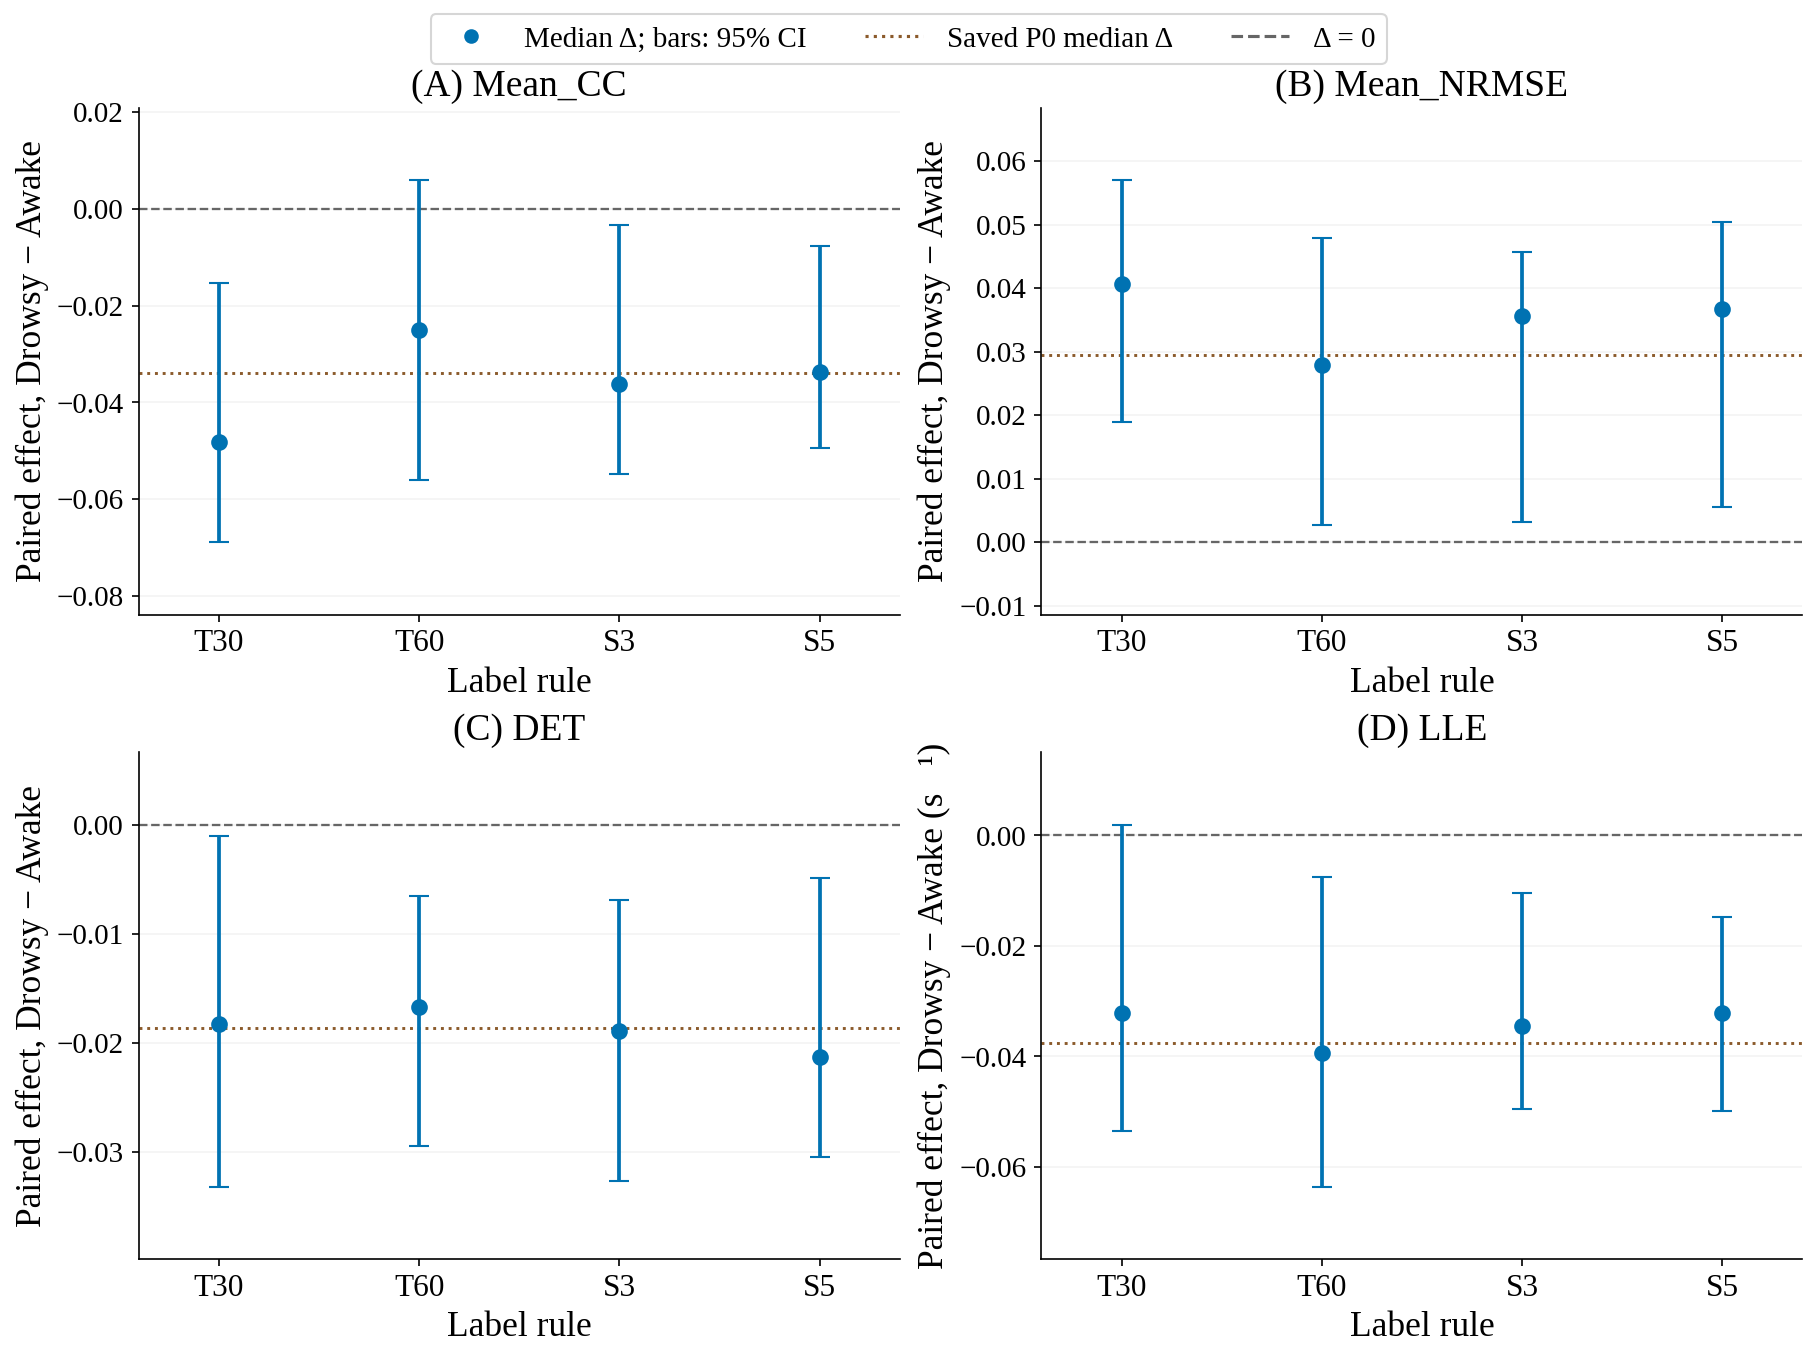

Inline figure font: Liberation Serif. No figure file exported.


In [7]:
font_names={f.name for f in font_manager.fontManager.ttflist}
PLOT_FONT="Times New Roman" if "Times New Roman" in font_names else "Liberation Serif"
font_manager.findfont(font_manager.FontProperties(family=PLOT_FONT),fallback_to_default=False)
style={"font.family":PLOT_FONT,"font.size":16,"axes.labelsize":17,"axes.titlesize":18,
       "xtick.labelsize":15,"ytick.labelsize":14,"legend.fontsize":14,
       "axes.spines.top":False,"axes.spines.right":False,"svg.fonttype":"path",
       "pdf.fonttype":42,"figure.dpi":150,"axes.unicode_minus":True}
with mpl.rc_context(style):
    fig,axes=plt.subplots(2,2,figsize=(12,9),layout="constrained")
    for ax,metric,panel in zip(axes.flat,METRICS,["A","B","C","D"]):
        data=label_sensitivity_statistics[label_sensitivity_statistics.metric==metric].set_index("rule").loc[list(RULES)]
        y=data.median_delta.to_numpy()
        errors=np.vstack([y-data.ci95_low,data.ci95_high-y])
        require((errors>=0).all(),"CI does not contain median; inspect before plotting")
        ax.axhline(0,color=".4",linestyle="--",linewidth=1.1)
        ax.axhline(float(p0.loc[metric,"median_delta"]),color="#8B5A2B",linestyle=":",linewidth=1.4)
        ax.errorbar(np.arange(4),y,yerr=errors,fmt="o",color="#0072B2",markersize=7,capsize=5,elinewidth=1.8)
        ax.set(xticks=np.arange(4),xticklabels=RULES,xlim=(-.4,3.4),title=f"({panel}) {metric}",xlabel="Label rule")
        ax.set_ylabel("Paired effect, Drowsy − Awake"+(" (s⁻¹)" if metric=="LLE" else ""))
        ax.grid(axis="y",alpha=.15)
        ax.margins(y=.20)
    fig.legend(handles=[Line2D([0],[0],color="#0072B2",marker="o",linestyle="none",label="Median Δ; bars: 95% CI"),
                        Line2D([0],[0],color="#8B5A2B",linestyle=":",label="Saved P0 median Δ"),
                        Line2D([0],[0],color=".4",linestyle="--",label="Δ = 0")],loc="outside upper center",ncol=3)
    display(fig)
    plt.close(fig)
print(f"Inline figure font: {PLOT_FONT}. No figure file exported.")

## Completion checks and observed summary

Direction, session consistency and statistical support are reported separately. These results do not compare rules statistically and do not establish physiological mechanisms. P0 and the sensitivity rules use the confirmed session × state estimator described above. Effect-magnitude comparisons remain descriptive, without a formal equivalence test.

In [8]:
require(len(label_sensitivity_statistics)==16,"Expected 16 sensitivity tests")
require(label_sensitivity_statistics.groupby("rule").size().eq(4).all(),"FDR families changed")
require(np.isfinite(label_sensitivity_statistics[["median_delta","ci95_low","ci95_high","p","q_BH","r_rb"]]).all().all(),"Nonfinite inference result")
require(label_sensitivity_statistics[["n_positive","n_negative","n_zero"]].sum(axis=1).eq(label_sensitivity_statistics.n).all(),"Direction counts mismatch")
for entry in manifest:
    require(digest(PHASE1_DIR/entry["file"])==entry["sha256"],"Input file changed")
lines=["### Kết quả đã tính", "", "- 16 kiểm định, BH-FDR riêng cho 4 metrics trong mỗi rule; bootstrap 20.000 paired-session resamples."]
for metric in METRICS:
    group=label_sensitivity_statistics[label_sensitivity_statistics.metric==metric]
    lines.append(f"- **{metric}**: cùng hướng kỳ vọng trong {int(group.direction_preserved.sum())}/4 rule; q_BH <0,05 trong {int(group.BH_supported.sum())}/4 rule.")
lines += ["", "T30/T60/S3 có 20 paired sessions; S5 có 19 cho mỗi metric sau QC. Sessions 09/13 được giữ. "
          "Không kiểm định giữa các rule; không chạy lại P0 hay NTSA. Toàn bộ bảng và figure nằm trong notebook."]
display(Markdown("\n".join(lines)))

### Kết quả đã tính

- 16 kiểm định, BH-FDR riêng cho 4 metrics trong mỗi rule; bootstrap 20.000 paired-session resamples.
- **Mean_CC**: cùng hướng kỳ vọng trong 4/4 rule; q_BH <0,05 trong 4/4 rule.
- **Mean_NRMSE**: cùng hướng kỳ vọng trong 4/4 rule; q_BH <0,05 trong 4/4 rule.
- **DET**: cùng hướng kỳ vọng trong 4/4 rule; q_BH <0,05 trong 4/4 rule.
- **LLE**: cùng hướng kỳ vọng trong 4/4 rule; q_BH <0,05 trong 4/4 rule.

T30/T60/S3 có 20 paired sessions; S5 có 19 cho mỗi metric sau QC. Sessions 09/13 được giữ. Không kiểm định giữa các rule; không chạy lại P0 hay NTSA. Toàn bộ bảng và figure nằm trong notebook.

## Tổng hợp kết quả Phase B2 — Label sensitivity

*Số liệu lấy từ các output đã lưu trong notebook; không chạy lại phân tích khi tạo phần tổng hợp này.*

### 1. Dữ liệu và framework đã sử dụng

- Đã phân tích **4 label rule: T30, T60, S3, S5**, với **4 headline metrics**: Mean_CC, Mean_NRMSE, DET và LLE.
- Mỗi giá trị session × state là **median của các window 60 s hợp lệ**; paired effect được tính bằng **Δ = Drowsy − Awake**.
- **T30/T60/S3: 20 paired sessions; S5: 19 paired sessions** cho mỗi metric. Session 15 của S5 không có window Drowsy hợp lệ nên không tạo được cặp; không có quyết định loại session thủ công. Sessions 09/13 được giữ.
- LLE dùng QC chính **R² ≥ 0,90**. Không dùng ngưỡng 0,95 để thay thế QC chính.
- Đã thực hiện **16 kiểm định**, với percentile bootstrap **20.000 lần** trên paired-session Δ, Wilcoxon hai phía, matched-pairs rank-biserial correlation và direction count.
- BH-FDR được áp dụng **riêng cho 4 metrics trong từng rule**, tạo 4 FDR families.

### 2. Kết quả thống kê

Direction count là số paired sessions có Δ theo hướng kỳ vọng: Mean_CC ↓, Mean_NRMSE ↑, DET ↓, LLE ↓. LLE có đơn vị s⁻¹; các metric còn lại không có đơn vị.

| Rule | Metric | n | Median Δ | Bootstrap 95% CI | r_rb | Direction count | p | q_BH |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| T30 | Mean_CC | 20 | -0.0482 | [-0.0689, -0.0152] | -0.695 | 17/20 | 0.0048599 | 0.0097198 |
| T30 | Mean_NRMSE | 20 | +0.0406 | [+0.0190, +0.0570] | +0.724 | 16/20 | 0.0031528 | 0.0097198 |
| T30 | DET | 20 | -0.0183 | [-0.0332, -0.0011] | -0.657 | 14/20 | 0.0083084 | 0.011078 |
| T30 | LLE | 20 | -0.0322 | [-0.0535, +0.0020] | -0.581 | 14/20 | 0.021484 | 0.021484 |
| T60 | Mean_CC | 20 | -0.0251 | [-0.0561, +0.0059] | -0.524 | 13/20 | 0.039989 | 0.039989 |
| T60 | Mean_NRMSE | 20 | +0.0278 | [+0.0027, +0.0479] | +0.619 | 14/20 | 0.013617 | 0.025645 |
| T60 | DET | 20 | -0.0167 | [-0.0294, -0.0066] | -0.590 | 15/20 | 0.019234 | 0.025645 |
| T60 | LLE | 20 | -0.0393 | [-0.0636, -0.0075] | -0.743 | 15/20 | 0.0023251 | 0.0093002 |
| S3 | Mean_CC | 20 | -0.0361 | [-0.0548, -0.0033] | -0.638 | 14/20 | 0.010689 | 0.013617 |
| S3 | Mean_NRMSE | 20 | +0.0357 | [+0.0032, +0.0457] | +0.676 | 15/20 | 0.0063896 | 0.012779 |
| S3 | DET | 20 | -0.0189 | [-0.0326, -0.0069] | -0.619 | 15/20 | 0.013617 | 0.013617 |
| S3 | LLE | 20 | -0.0344 | [-0.0495, -0.0104] | -0.790 | 15/20 | 0.0010166 | 0.0040665 |
| S5 | Mean_CC | 19 | -0.0337 | [-0.0495, -0.0077] | -0.642 | 14/19 | 0.01236 | 0.014069 |
| S5 | Mean_NRMSE | 19 | +0.0367 | [+0.0056, +0.0504] | +0.716 | 16/19 | 0.0045776 | 0.0091553 |
| S5 | DET | 19 | -0.0213 | [-0.0305, -0.0049] | -0.632 | 15/19 | 0.014069 | 0.014069 |
| S5 | LLE | 19 | -0.0321 | [-0.0499, -0.0147] | -0.789 | 14/19 | 0.0014114 | 0.0056458 |

### 3. Đối chiếu median Δ với P0 đã lưu

| Metric | P0 Δ | T30 Δ | T60 Δ | S3 Δ | S5 Δ | Cùng hướng P0 |
| --- | --- | --- | --- | --- | --- | --- |
| Mean_CC | -0.0339 | -0.0482 | -0.0251 | -0.0361 | -0.0337 | Có, 4/4 rule |
| Mean_NRMSE | +0.0294 | +0.0406 | +0.0278 | +0.0357 | +0.0367 | Có, 4/4 rule |
| DET | -0.0186 | -0.0183 | -0.0167 | -0.0189 | -0.0213 | Có, 4/4 rule |
| LLE | -0.0376 | -0.0322 | -0.0393 | -0.0344 | -0.0321 | Có, 4/4 rule |

- **16/16 median Δ** theo hướng kỳ vọng; mỗi metric giữ hướng trong **4/4 rule**.
- **16/16 kiểm định có q_BH < 0,05** theo FDR family riêng từng rule.
- **14/16 bootstrap 95% CI không chứa 0**. Hai CI chứa 0 là **T60–Mean_CC** `[-0.0561, +0.0059]` và **T30–LLE** `[-0.0535, +0.0020]`.
- Các cờ q_BH và CI được báo riêng: kiểm định signed-rank và bootstrap CI của median Δ là hai kết quả suy luận khác nhau.

### 4. Quy ước cần giữ khi đọc đối chiếu P0

- Theo pipeline được xác nhận ở bước finalize, **P0 và B2 dùng cùng estimator ở cấp session × state**: window 60 s → CC/NRMSE trên 18 horizons → Mean_CC/Mean_NRMSE của window → median qua các window hợp lệ trong session × state → Δ = Drowsy − Awake. Vì vậy, direction, effect magnitude và session consistency được đối chiếu trực tiếp giữa P0 và T30/T60/S3/S5.
- P0 đã hiệu chỉnh BH trên **7 metrics**, còn B2 dùng **4 headline metrics trong mỗi rule** theo thiết kế hiện tại. Không tính lại p hoặc q của P0.
- Các `effect_ratio = |Δ_rule| / |Δ_P0|` trong bảng phía trên chỉ là mô tả; không áp dụng ngưỡng cứng và không kiểm định trực tiếp giữa các rule.

### 5. Kết quả đã hoàn thành trong notebook

- Bảng kiểm tra window hợp lệ và paired-session coverage theo rule × metric.
- Bảng thống kê 16 dòng, bảng đối chiếu P0, effect ratios và bảng tổng hợp direction/BH support.
- **Một figure 2×2** cho Mean_CC, Mean_NRMSE, DET và LLE: median paired Δ, bootstrap 95% CI, đường Δ = 0 và đường P0 tham chiếu; font serif, SVG/PNG inline, không mã hóa màu theo significance.
- Kiểm tra số cặp, direction counts, FDR families và fingerprint dữ liệu đầu vào đã hoàn tất.

Toàn bộ kết quả chỉ nằm trong notebook. Không xuất file kết quả riêng, không chạy lại NTSA hoặc thống kê P0, không relabel, không gộp rule và không diễn giải cơ chế sinh lý.


## Final conclusion — Label Verification

**Label Verification Status: COMPLETE**  
**Frozen finding status: ROBUST TO LABEL-SELECTION SENSITIVITY**

### Final robustness summary

| Metric | P0 Δ | T30 Δ | T60 Δ | S3 Δ | S5 Δ | Direction preserved |
|---|---:|---:|---:|---:|---:|---:|
| Mean_CC | -0.0339 | -0.0482 | -0.0251 | -0.0361 | -0.0337 | 4/4 |
| Mean_NRMSE | +0.0294 | +0.0406 | +0.0278 | +0.0357 | +0.0367 | 4/4 |
| DET | -0.0186 | -0.0183 | -0.0167 | -0.0189 | -0.0213 | 4/4 |
| LLE | -0.0376 | -0.0322 | -0.0393 | -0.0344 | -0.0321 | 4/4 |

Các giá trị là median paired Δ = Drowsy − Awake, được giữ nguyên từ kết quả đã có.

- **16/16 paired effects** giữ đúng hướng kỳ vọng.
- **16/16 kiểm định có q_BH < 0,05**, với BH-FDR riêng cho 4 headline metrics trong từng rule.
- **14/16 bootstrap 95% CI không chứa 0**.
- Hai CI chứa 0 là **T60–Mean_CC** và **T30–LLE**. Hai trường hợp này vẫn giữ hướng median Δ và rank-biserial, có hỗ trợ Wilcoxon/BH-FDR, và cùng hướng với các rule còn lại; không được coi riêng lẻ là failure của label verification.
- **T30/T60/S3: n = 20 paired sessions; S5: n = 19**. Sessions 09 và 13 vẫn được giữ.
- Giữ nguyên median Δ, percentile bootstrap 95% CI với **20.000 paired-session resamples**, Wilcoxon hai phía, matched-pairs rank-biserial correlation và direction counts.

### Final interpretation

Processed dataset đã vượt qua kiểm tra tính toàn vẹn cấu trúc; các khoảng trống thời gian đã ghi nhận trong Phase A vẫn được giữ trong audit và không được nội suy.

Các finding chính của RQ2 — **Mean_CC ↓, Mean_NRMSE ↑, DET ↓ và LLE ↓** — giữ nguyên hướng dưới toàn bộ bốn cách chọn nhãn bảo thủ T30, T60, S3 và S5. Độ lớn hiệu ứng nhìn chung tương đương với P0 ở mức mô tả, và toàn bộ 16 phép kiểm định vẫn được hỗ trợ sau BH-FDR. Điều này cho thấy các kết luận Awake–Drowsy không phụ thuộc mạnh vào các vùng nhãn gần transition hoặc các đoạn trạng thái ngắn trong phạm vi các điều kiện đã khảo sát.

**Kết quả RQ2 robust đối với các biến thể hợp lý và bảo thủ của label selection đã kiểm tra.** Nhận định về độ lớn là mô tả, không phải kết quả của một kiểm định tương đương. Kết luận không xác lập KSS là ground truth khách quan và không khẳng định label uncertainty đã bị loại bỏ hoàn toàn.

### Frozen label rules and findings

| Rule | Frozen definition |
|---|---|
| P0 | Primary labels |
| T30 | Exclude samples within ±30 s of Awake ↔ Drowsy transitions |
| T60 | Exclude samples within ±60 s of Awake ↔ Drowsy transitions |
| S3 | Retain contiguous state segments ≥180 s |
| S5 | Retain contiguous state segments ≥300 s |

**Frozen findings:** Mean_CC ↓; Mean_NRMSE ↑; DET ↓; LLE ↓.  
**Level:** ROBUST TO LABEL-SELECTION SENSITIVITY.

Nhánh label verification được đóng tại đây. Không mở rộng sang T90, kết hợp transition/segment rules, relabeling, smoothing, post-hoc session exclusion hoặc ngưỡng label khác, trừ khi có yêu cầu cụ thể từ reviewer/prof sau này.

### Next verification target

**NTSA parameter dependence / method-specific robustness.**

Bước finalize này chỉ cập nhật mô tả, kết luận và trạng thái freeze trong notebook. Không chạy lại NTSA hoặc thống kê; không thay đổi kết quả số, figure hay bất kỳ file kết quả đã lưu nào.


## Chốt ý nghĩa của các label-sensitivity rules

P0, S3 và S5 đều sử dụng cùng cửa sổ 60 s. Khác biệt nằm ở **đoạn trạng thái nào được phép đóng góp window vào phân tích**:

- **P0:** sử dụng mọi đoạn Awake/Drowsy hợp lệ.
- **S3:** chỉ sử dụng các đoạn trạng thái kéo dài ít nhất 3 phút.
- **S5:** chỉ sử dụng các đoạn trạng thái kéo dài ít nhất 5 phút.

Kết quả cho thấy `CC↓, NRMSE↑, DET↓, LLE↓` vẫn giữ ở cả S3 và S5.

> Điều này cho thấy các finding chính không được tạo ra chủ yếu bởi những episode Awake/Drowsy ngắn, phân mảnh hoặc chập chờn.

T30 và T60 kiểm tra một nguồn bất định khác:

- **T30:** loại dữ liệu trong ±30 s quanh mỗi điểm chuyển trạng thái.
- **T60:** loại dữ liệu trong ±60 s quanh mỗi điểm chuyển trạng thái.

Kết quả vẫn giữ dưới cả T30 và T60.

> Điều này cho thấy các finding chính không phụ thuộc chủ yếu vào dữ liệu nằm sát ranh giới Awake–Drowsy, nơi trạng thái sinh lý và nhãn có khả năng bất định hơn.

Tóm lại:

> **T30/T60 kiểm tra độ nhạy với vùng chuyển trạng thái; S3/S5 kiểm tra độ nhạy với độ bền thời gian của trạng thái. Việc các finding giữ nguyên dưới cả hai nhóm rule cung cấp bằng chứng rằng kết luận RQ2 không bị chi phối bởi những phần label dễ gây nghi ngờ nhất.**